**Ćwiczenie 1: Kodowanie znaków**

In [2]:
import pandas as pd

utf8 = pd.read_csv("pracownicy_utf8.csv")
print(utf8)

cp1250 = pd.read_csv("pracownicy_cp1250.csv")
print(cp1250)

      imie    nazwisko     miasto    stanowisko
0     Anna   Kowalczyk       Łódź      inżynier
1   Bartek       Żurek     Kraków      analityk
2   Celina      Ślązak     Gdańsk     kierownik
3   Damian      Wójcik     Poznań   programista
4      Ewa       Łęcka   Warszawa      księgowa
5    Filip        Król    Wrocław      inżynier
6  Grażyna  Piątkowska       Łódź      dyrektor
7   Henryk   Dąbrowski   Szczecin      analityk
8    Irena       Nowak   Katowice  programistka
9      Jan       Góral  Białystok     kierownik


UnicodeDecodeError: 'utf-8' codec can't decode byte 0xa3 in position 48: invalid start byte

In [3]:
utf8 = pd.read_csv("pracownicy_utf8.csv", encoding="cp1250")
print(utf8)

cp1250 = pd.read_csv("pracownicy_cp1250.csv", encoding="utf-8")
print(cp1250)

UnicodeDecodeError: 'charmap' codec can't decode byte 0x81 in position 49: character maps to <undefined>

In [4]:
cp1250 = pd.read_csv("pracownicy_cp1250.csv", encoding="cp1250")
print(cp1250)
print("\n")

cp1250.to_csv("cp1250_as_utf-8.csv", encoding="utf-8")

cp1250_as_utf8 = pd.read_csv("cp1250_as_utf-8.csv")
print(cp1250_as_utf8)

      imie    nazwisko     miasto    stanowisko
0     Anna   Kowalczyk       Łódź      inżynier
1   Bartek       Żurek     Kraków      analityk
2   Celina      Ślązak     Gdańsk     kierownik
3   Damian      Wójcik     Poznań   programista
4      Ewa       Łęcka   Warszawa      księgowa
5    Filip        Król    Wrocław      inżynier
6  Grażyna  Piątkowska       Łódź      dyrektor
7   Henryk   Dąbrowski   Szczecin      analityk
8    Irena       Nowak   Katowice  programistka
9      Jan       Góral  Białystok     kierownik


   Unnamed: 0     imie    nazwisko     miasto    stanowisko
0           0     Anna   Kowalczyk       Łódź      inżynier
1           1   Bartek       Żurek     Kraków      analityk
2           2   Celina      Ślązak     Gdańsk     kierownik
3           3   Damian      Wójcik     Poznań   programista
4           4      Ewa       Łęcka   Warszawa      księgowa
5           5    Filip        Król    Wrocław      inżynier
6           6  Grażyna  Piątkowska       Łódź     

1. Bez podawania parametru `encoding`, niepoprawnie wczytał się plik *pracownicy_cp1250.csv*. Jest to spowodowane różnicą w stronie kodowania. Domyślnie funkcja `read_csv` wczytuje dane z encodingiem UTF-8. Chcąc zdekodować plik z kodowaniem CP1250 tak jakby był on zapisany w UTF-8 otrzymujemy błąd.

2. W moim przypadku w obu plikach wczytując je z przeciwnym encodingiem otrzymałem *UnicodeDecodeError*.

3. Zapisując plik z kodowaniem `cp1250` jako `utf-8`, błąd pojawił się w pierwszej, dodatkowej kolumnie.

**Ćwiczenie 2: Brudny CSV**

In [5]:
df = pd.read_csv("klienci.csv")

UnicodeDecodeError: 'utf-8' codec can't decode byte 0xb3 in position 98: invalid start byte

In [35]:
clients = pd.read_csv("klienci.csv", encoding="cp1250", sep=";",
                      decimal=",",
                      na_values=["brak", "-", "?"],
                      dtype={"kod_pocztowy": str})

clients["data_rejestracji"] = pd.to_datetime(
    clients["data_rejestracji"],
    dayfirst=True
)

print(clients)
print("\n")
print("Typy danych:")
print(clients.dtypes)

    id kod_pocztowy data_rejestracji     miasto                         adres  \
0    1       00-001       2023-03-15   Warszawa           ul. Marszałkowska 1   
1    2       90-001       2022-07-22       Łódź           ul. Piotrkowska 100   
2    3       31-000       2024-01-01     Kraków      ul. Floriańska 5; lok. 3   
3    4       80-001       2021-11-12     Gdańsk                  ul. Długa 15   
4    5       50-001       2023-06-30    Wrocław               ul. Świdnicka 8   
5    6       60-001       2022-09-05     Poznań             ul. Półwiejska 22   
6    7       90-002       2024-02-18       Łódź   ul. Narutowicza 7; piętro 2   
7    8       40-001       2023-05-25   Katowice                 ul. 3 Maja 11   
8    9       70-001       2022-08-10   Szczecin       al. Wojska Polskiego 50   
9   10       15-001       2023-12-03  Białystok                  ul. Lipowa 3   
10  11       00-002       2024-04-14   Warszawa             ul. Nowy Świat 21   
11  12       90-003       20

In [45]:
lodz = clients[clients["miasto"] == "Łódź"]

liczba = len(lodz)
sredni_dochod = lodz["dochod"].mean()

print(liczba)
print(sredni_dochod)

3
3783.5833333333335


In [83]:
import os

clients.to_parquet("klienci.parquet")

csv_size = os.path.getsize("klienci.csv")
parquet_size = os.path.getsize("klienci.parquet")

print(csv_size, parquet_size)

924 5639


1. Przy wczytywaniu pliku `klienci.csv` najprostszą metodą, pojawia się ten sam błąd dotyczący strony kodowania - nie można wczytać pliku zakodowanego jako *cp1250* z domyślnym encodingiem *utf-8*.

3. Po wprowadzeniu zmian myślę, że typy danych są prawidłowe.

4. Trzech klientów było z miasta Łodzi, ich średni dochód wyniósł 3784,58 zł.

5. Rozmiar pliku w formacie `csv` okazał się u mnie pięciokrotnie mniejszy niż format `parquet`

**Ćwiczenie 3: Pobieranie danych z API NBP**

dict_keys(['table', 'currency', 'code', 'rates'])


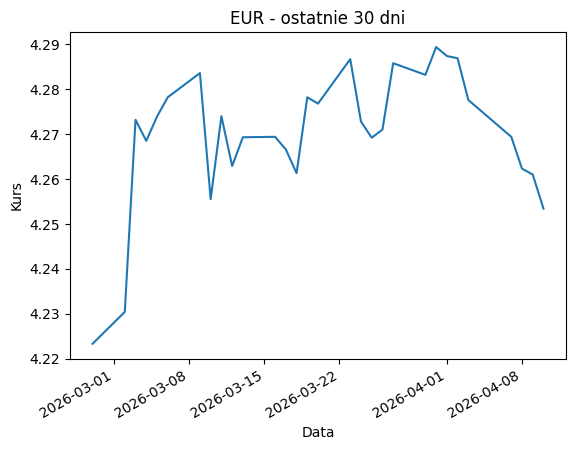

<Figure size 640x480 with 0 Axes>

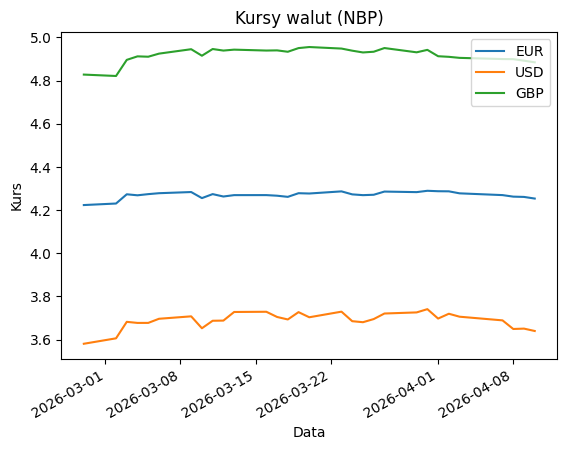

In [71]:
import requests
import matplotlib.pyplot as plt

url = "https://api.nbp.pl/api/exchangerates/rates/A/EUR/last/30/?format=json"

response = requests.get(url)
data = response.json()

print(data.keys())


df_eur = pd.DataFrame(data["rates"])

df_eur["effectiveDate"] = pd.to_datetime(df_eur["effectiveDate"])
df_eur = df_eur.set_index("effectiveDate")

df_eur = df_eur.rename(columns={"mid": "EUR"})

plt.figure()
df_eur["EUR"].plot()
plt.title("EUR - ostatnie 30 dni")
plt.xlabel("Data")
plt.ylabel("Kurs")
plt.show()

def fetch_currency(code):
    url = f"https://api.nbp.pl/api/exchangerates/rates/A/{code}/last/30/?format=json"
    data = requests.get(url).json()

    df = pd.DataFrame(data["rates"])
    df["effectiveDate"] = pd.to_datetime(df["effectiveDate"])
    df = df.set_index("effectiveDate")
    df = df.rename(columns={"mid": code})

    return df[[code]]

df_eur = fetch_currency("EUR")
df_usd = fetch_currency("USD")
df_gbp = fetch_currency("GBP")

df_all = pd.concat([df_eur, df_usd, df_gbp], axis=1)

plt.figure()
df_all.plot()
plt.title("Kursy walut (NBP)")
plt.xlabel("Data")
plt.ylabel("Kurs")
plt.show()

df_all.to_parquet("nbp.parquet", index=True)

**Ćwiczenie 4: Benchmark formatów**

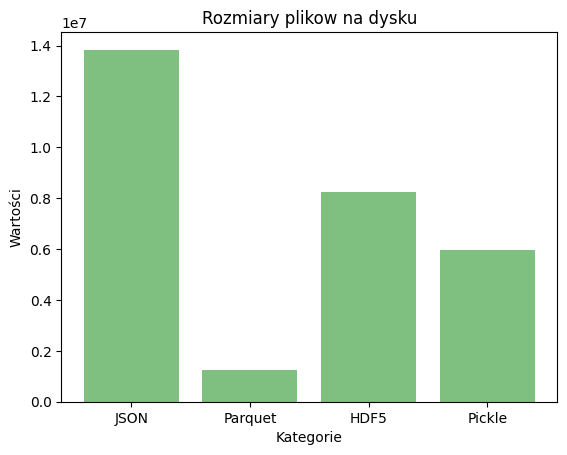

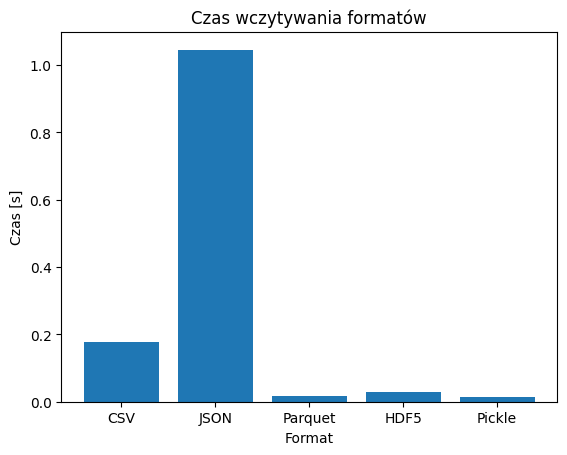

Parquet - wszystkie kolumny: 0.019312550800168537
Parquet - 2 kolumny: 0.008375378199889382


In [91]:
import time

pomiary = pd.read_csv("pomiary.csv")

pomiary.to_json("pomiary.json")
pomiary.to_parquet("pomiary.parquet")
pomiary.to_hdf("pomiary.h5", key="pomiary", mode="w")
pomiary.to_pickle("pomiary.pickle")

json_size = os.path.getsize("pomiary.json")
parquet_size = os.path.getsize("pomiary.parquet")
hdf_size = os.path.getsize("pomiary.h5")
pickle_size = os.path.getsize("pomiary.pickle")

names = ("JSON", "Parquet", "HDF5", "Pickle")
sizes = (json_size, parquet_size, hdf_size, pickle_size)

plt.bar(names, sizes, color='green', alpha=0.5)

plt.title('Rozmiary plikow na dysku')
plt.xlabel('Kategorie')
plt.ylabel('Wartości')

plt.show()

def measure_time(func, n=5):
    times = []
    for _ in range(n):
        start = time.perf_counter()
        func()
        end = time.perf_counter()
        times.append(end - start)
    return sum(times) / len(times)

times = {}

times["CSV"] = measure_time(lambda: pd.read_csv("pomiary.csv"))
times["JSON"] = measure_time(lambda: pd.read_json("pomiary.json"))
times["Parquet"] = measure_time(lambda: pd.read_parquet("pomiary.parquet"))
times["HDF5"] = measure_time(lambda: pd.read_hdf("pomiary.h5", key="pomiary"))
times["Pickle"] = measure_time(lambda: pd.read_pickle("pomiary.pickle"))

plt.figure()
plt.bar(times.keys(), times.values())

plt.title("Czas wczytywania formatów")
plt.xlabel("Format")
plt.ylabel("Czas [s]")

plt.show()

t_all = measure_time(lambda: pd.read_parquet("pomiary.parquet"))

t_subset = measure_time(lambda: pd.read_parquet(
    "pomiary.parquet",
    columns=["date", "pm25"]
))

print("Parquet - wszystkie kolumny:", t_all)
print("Parquet - 2 kolumny:", t_subset)

5. W związku z tym jak szybko zajmuje wczytywanie i jak mało waży na dysku format `parquet`, to właśnie jego wybrałbym na przechowywanie danych długoterminowo i do szybkich analiz.

**Ćwiczenie 5: SQLite i pandas**

In [89]:
import sqlite3

conn = sqlite3.connect("sklep.db")

tables = pd.read_sql_query("""
SELECT name
FROM sqlite_master
WHERE type='table';
""", conn)

print(tables)
print("\n")

klienci = pd.read_sql_query("SELECT * FROM klienci", conn)
produkty = pd.read_sql_query("SELECT * FROM produkty", conn)
zamowienia = pd.read_sql_query("SELECT * FROM zamowienia", conn)

print("Rozmiary:")
print(klienci.shape)
print(produkty.shape)
print(zamowienia.shape)
print("\n")

print("Typy kolumn:")
print(klienci.dtypes)
print("\n")
print(produkty.dtypes)
print("\n")
print(zamowienia.dtypes)
print("\n")

print("10 klientów z największą liczbą zamówień")
top_klienci = pd.read_sql_query("""
SELECT k.id, k.imie, k.nazwisko, COUNT(z.id) AS liczba_zamowien
FROM klienci k
JOIN zamowienia z ON k.id = z.klient_id
GROUP BY k.id
ORDER BY liczba_zamowien DESC
LIMIT 10;
""", conn)

print(top_klienci)

         name
0     klienci
1    produkty
2  zamowienia


Rozmiary:
(200, 6)
(15, 4)
(1000, 5)


Typy kolumn:
id                   int64
imie                object
nazwisko            object
miasto              object
wiek                 int64
data_rejestracji    object
dtype: object


id             int64
nazwa         object
kategoria     object
cena         float64
dtype: object


id                  int64
klient_id           int64
produkt_id          int64
ilosc               int64
data_zamowienia    object
dtype: object


10 klientów z największą liczbą zamówień
    id     imie    nazwisko  liczba_zamowien
0  174    Piotr      Wójcik               10
1  170  Grażyna     Woźniak               10
2   72   Michał     Woźniak               10
3  166     Adam    Kamiński                9
4  164   Tomasz  Wiśniewski                9
5  163   Damian    Kowalski                9
6  147    Maria     Woźniak                9
7  138   Michał   Kozłowski                9
8  102    Filip   Ko